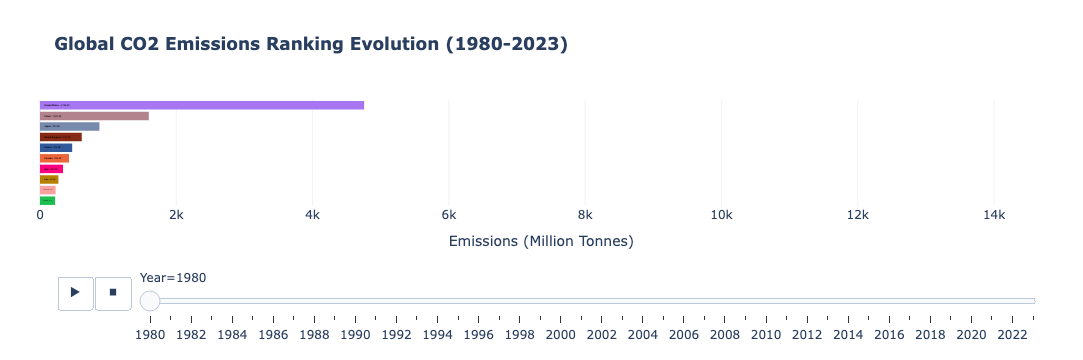

🎉 Success! The smooth English Bar Chart Race is ready.


In [4]:
import pandas as pd
import plotly.express as px
import os

# 1. Load and Clean Data
file_path = 'Data/Cleaned/Master_CO2_Decoupling_Final.csv'
df = pd.read_csv(file_path)

# Ensure numeric and integer formats
df['CO2_Emission'] = pd.to_numeric(df['CO2_Emission'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype(int)
df = df.dropna(subset=['CO2_Emission', 'Year'])

# Assign a unique color to every country once to prevent flickering
all_countries = df['Country'].unique()
colors = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24
color_map = {country: colors[i % len(colors)] for i, country in enumerate(all_countries)}

# 2. Data Preparation: Rankings and Buffers
top_n_display = 10
buffer_size = 5

# Calculate Rank per year
df['Rank'] = df.groupby('Year')['CO2_Emission'].rank(method='first', ascending=False)
# Keep Top 15 to ensure smooth sliding for the Top 10
df_race = df[df['Rank'] <= (top_n_display + buffer_size)].copy()

# Format the labels (Country Name + Value)
df_race['Label'] = df_race.apply(lambda x: f"  <b>{x['Country']}</b> : {x['CO2_Emission']:,.0f} Mt", axis=1)

# Sort by Year and Rank for animation logic
df_race = df_race.sort_values(['Year', 'Rank'])

# 3. Create Plotly Animation
fig = px.bar(
    df_race,
    x='CO2_Emission',
    y='Rank',
    color='Country',
    color_discrete_map=color_map, # Fix colors for every country
    animation_frame='Year',
    animation_group='Country', 
    orientation='h',
    text='Label',
    range_x=[0, df_race['CO2_Emission'].max() * 1.2], # Space for labels
    range_y=[top_n_display + 0.5, 0.5],             # Lock View to Top 10
    title='<b>Global CO2 Emissions Ranking Evolution (1980-2023)</b>',
    labels={
        'CO2_Emission': 'CO2 Emissions (Million Tonnes)',
        'Rank': 'Global Rank',
        'Year': 'Year'
    }
)

# 4. Refine Traces: Lock Text to the "Driver's Seat"
fig.update_traces(
    textposition='inside',       
    insidetextanchor='start',    # Anchor text to the far left of the bar
    textfont=dict(
        size=15, 
        color='black',           # High contrast black text
        family='Arial'
    ),
    marker=dict(line=dict(width=0)) # Remove borders to stop anti-aliasing jitter
)

# ==========================================
# 🌟 STABILITY FIX: Animation Engine Tuning 🌟
# ==========================================
duration = 1000 # 1 second per year

# Frame duration and Redraw control
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = duration
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['redraw'] = False   # Disable full redraw for smooth interpolation
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = duration 
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['easing'] = 'linear' # Linear move is much more stable

# Slider sync
if fig.layout.sliders:
    for step in fig.layout.sliders[0].steps:
        step.args[1]['frame']['redraw'] = False

# 5. Layout Optimization: Industrial Dashboard Style
fig.update_layout(
    template='plotly_white',
    showlegend=False,
    margin=dict(l=40, r=40, t=100, b=40),
    yaxis=dict(
        autorange=False, 
        showticklabels=False, 
        title='',
        fixedrange=True
    ),
    xaxis=dict(
        showgrid=True, 
        gridcolor='rgba(230,230,230,0.5)', 
        title='Emissions (Million Tonnes)',
        fixedrange=True
    )
)

# 6. Render and Save Visualization

# Show the interactive figure in your environment
fig.show()

# Define the target directory for visualizations
output_dir = 'Output'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define the full path for the HTML file
output_path = os.path.join(output_dir, "Global_CO2_Ranking_Race.html")

# Save as HTML for sharing
fig.write_html(output_path)

print(f"🎉 Success! The smooth English Bar Chart Race is saved to: {output_path}")